# MNIST Dataset

MNIST is a dataset of **70,000 handwritten digit images** from 0 to 9.

Each image is **28 × 28 pixels**, resulting in **784 features** after flattening the image into a one-dimensional array.

* `X` → pixel values of the images
* `y` → corresponding digit labels
* Each pixel is a grayscale intensity value between **0 and 255**

The `sklearn.datasets` package provides three main types of functions:

* `fetch_*` → download real-world datasets.
* `load_*` → load small datasets bundled with Scikit-Learn.
* `make_*` → generate synthetic datasets for testing and experimentation.

Datasets may be returned as NumPy arrays, `(X, y)` tuples, or `Bunch` objects.

`fetch_openml()` returns Pandas objects by default, but `as_frame=False` can be used to get NumPy arrays, which is more convenient for datasets such as MNIST.



In [34]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=False)

X, y = mnist.data, mnist.target

Some Scikit-Learn datasets are returned as a `Bunch` object, which behaves like a dictionary and also allows attribute-style access.

Common entries include:

* `DESCR` → description of the dataset
* `data` → input features, usually a 2D NumPy array
* `target` → target labels, usually a 1D NumPy array


In [35]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [36]:
print(X.shape, X.dtype, sep=" | ")
print(y.shape, y.dtype, sep=" | ")


(70000, 784) | int64
(70000,) | object


In [37]:
y[0]

'5'

In [38]:
X[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

The output is not suitable for visualizing as an image, so let's reshape it back to its original `28 × 28` format.

# Reshaping MNIST Images

Each MNIST image is stored as a 1D array of 784 pixel values.

To visualize an image, we reshape it back to its original `28 × 28` format:

`784 → 28 × 28`

`reshape()` changes the shape of the array without changing its values.


In [52]:
X[10].reshape(28, 28)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  42, 118,
        219, 166, 118, 118,   6,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 103, 242, 254,
        254, 254, 254, 254,  66,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

# Visualizing MNIST Images

A helper function can be used to reshape a flattened MNIST image back to `28 × 28` and display it with Matplotlib.

This makes it easy to visualize different samples by passing their flattened pixel data to the function.


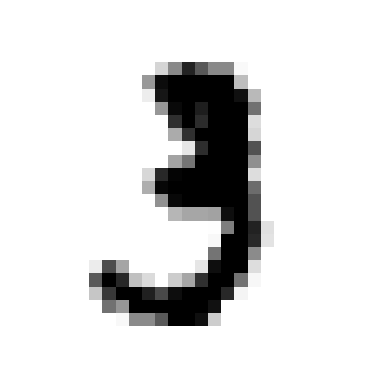

In [50]:
import matplotlib.pyplot as plt


def show_image(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()


some_digit = X[10]
show_image(some_digit)

In [48]:
y[10]

'3'

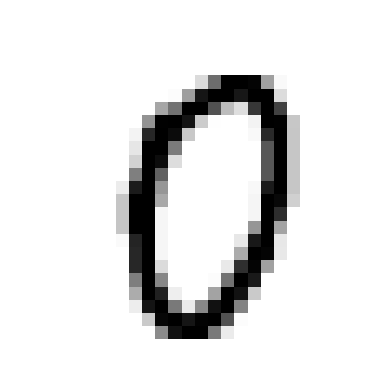

In [53]:
show_image(X[1000])

In [54]:
y[1000]

'0'

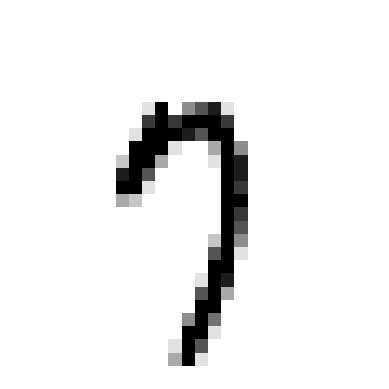

In [55]:
show_image(X[50021])

In [56]:
y[50021]

'7'

# MNIST Train/Test Split

The MNIST dataset already provides a standard split:

* **60,000 images** → training set
* **10,000 images** → test set

The test set should be kept separate and untouched until the final evaluation to avoid **data leakage** and obtain a reliable estimate of the model's generalization performance.


In [66]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Shuffling the Training Set

The MNIST training set is already shuffled.

Shuffling helps ensure that:

* Cross-validation folds contain a representative mix of classes.
* Order-sensitive learning algorithms do not receive many similar samples consecutively.

Shuffling is especially important for algorithms that process training instances sequentially, such as **Stochastic Gradient Descent (SGD)**.
